# Model Comparisons

In [1]:
from src.models import load_ml_model
from src.preprocessing import csv_handler

In [2]:
# loading data
random_forest = load_ml_model("rf.pkl")
gradient_boosting = load_ml_model("gb.pkl")
polynomial_regression = load_ml_model("pr.pkl")

In [3]:
from sklearn.metrics import r2_score
from src.preprocessing.csv_handler import load_data

In [4]:
X_test = load_data("X_test.csv")
y_test = load_data("y_test.csv")

In [6]:
random_forest_predictions = random_forest.predict(X_test)
gradient_boosting_predictions = gradient_boosting.predict(X_test)
polynomial_regression_predictions = polynomial_regression['model'].predict(X_test)

In [7]:
random_forest_r2 = r2_score(y_test, random_forest_predictions, multioutput='raw_values')
gradient_boosting_r2 = r2_score(y_test, gradient_boosting_predictions, multioutput='raw_values')
polynomial_regression_r2 = r2_score(y_test, polynomial_regression_predictions, multioutput='raw_values')

In [19]:
from src.utils.plotting import plot_score

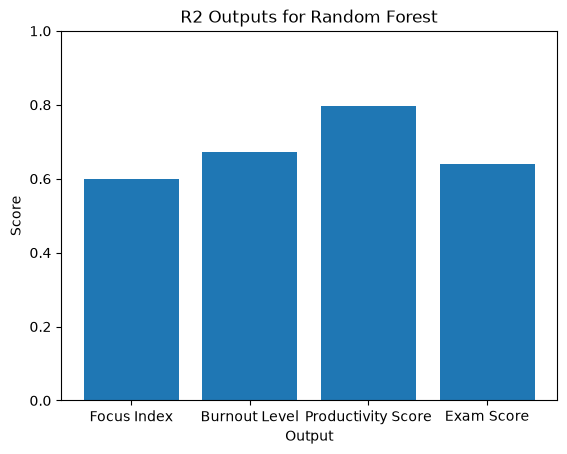

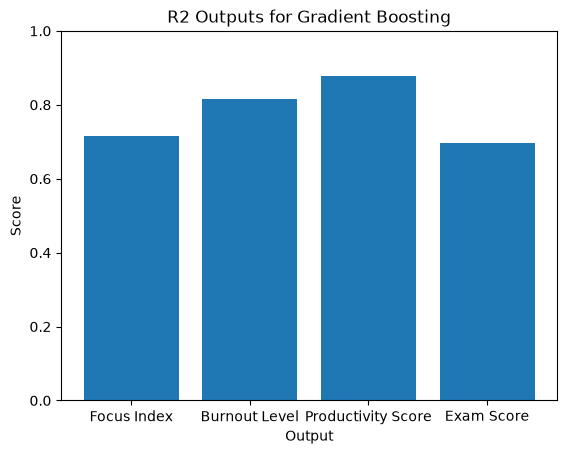

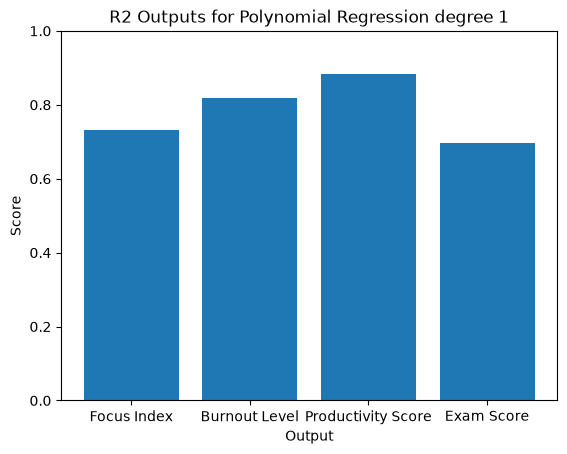

In [20]:
plot_score(random_forest_r2, "Random Forest")
plot_score(gradient_boosting_r2, "Gradient Boosting")
plot_score(polynomial_regression_r2, "Polynomial Regression degree " + str(polynomial_regression['degree']))

In [21]:
print("RF R2:", random_forest_r2)
print("GB R2:", gradient_boosting_r2)
print("PR R2:", polynomial_regression_r2)

RF R2: [0.59859008 0.67295754 0.79577058 0.63945719]
GB R2: [0.71513524 0.81494546 0.87878336 0.696775  ]
PR R2: [0.73174531 0.81732522 0.88322338 0.69685567]


## Conclusions
We can see from the R2 scores that polynomial regression has the highest overall R2 scores for every label. This model will give the most accurate predictions on new data.

## Bonus: Feature Impact Using Coefficient Values
### (Optional)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

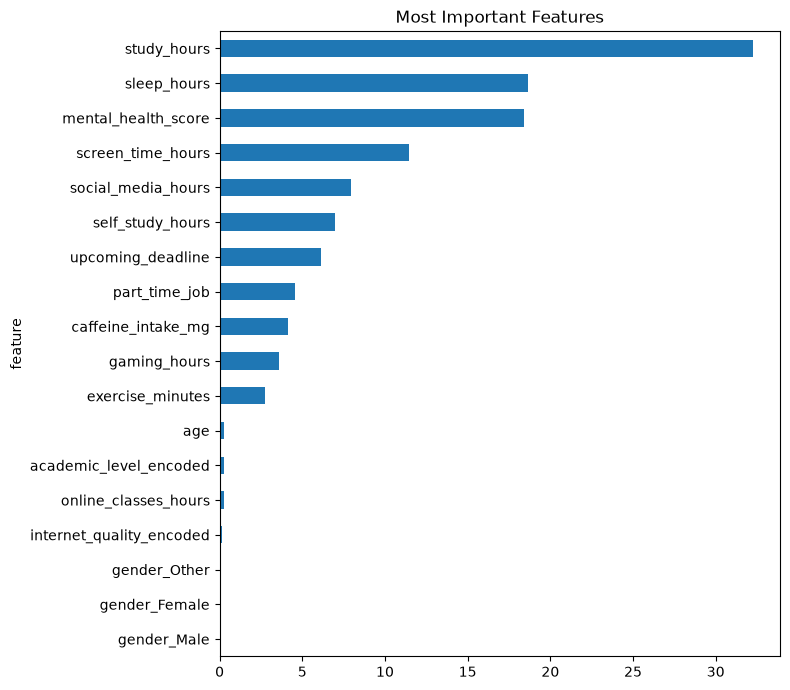

In [36]:
coefs = polynomial_regression['model'].named_steps["linear"].coef_

mean_abs_coefs = np.abs(coefs).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_coef": mean_abs_coefs[1:]
}).sort_values("mean_abs_coef", ascending=False)

importance_df.plot(
    x='feature', y='mean_abs_coef',
    kind='barh', figsize=(8, 7), legend=False
)

plt.title('Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

We can see that study hours, sleep hours, and mental health score have had the most impact on predictions.

**Note** _If the features are not all scaled this would not be accurate_